# Financial Stability Score Prediction Using Regression Models


The objective of this project is to build a predictive model that can estimate an individual's Financial Stability Score using different regression techniques. We'll be working with financial, demographic, and behavioral data to train our models.

To achieve this, we'll apply three supervised learning algorithms:

- ##### Linear Regression
- ##### Ridge Regression
- ##### Lasso Regression
The process will involve cleaning and preprocessing the dataset, handling missing values, encoding categorical variables, and training our models. We’ll compare their performance to determine which approach gives the most accurate and reliable predictions. The models will be developed and evaluated by the following students:
- ##### BAGUIO, RYAN S.
- ##### GAVIOLA, GEFF KENDRA C.
- ##### MAGHINAY, SHANE DARYL C.
- ##### PANONG, LUZINDA NIñA M.
- ##### RAAGAS, ANDREI G.
- ##### VILLAR, KAYE B.

### Import Libraries
Importing the necessary Python libraries for data manipulation, model training, evaluation, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score


### Show Dataset
Displaying the dataset to examine its structure, feature distribution, number of columns, null values, and target variable before applying machine learning models.

In [2]:
df = pd.read_csv('Financial Stability.csv')
df

,Salary,Work_Experience,Education_Level,Hours_Worked_Per_Week,Loan_Amount,Credit_Score,Marital_Status,House_Ownership,Number_of_Children,Job_Satisfaction,...,Number_of_Dependents,Previous_Loans,Loan_Default_History,Investment_in_Stocks,Savings_Account_Balance,Retirement_Fund,Mortgage_Status,Monthly_Expenses,Annual_Bonus,Financial_Stability_Score
0,37.454012,45,Master's,14,15.601864,NaN,Single,Other,3,70.807258,...,9,61.185289,13.949386,29.214465,36.636184,45.606998,Defaulted,19.967378,51.423444,1731.963403
1,59.241457,4,Bachelor's,17,6.505159,94.888554,Married,Mortgaged,6,9.767211,...,2,54.671028,18.485446,NaN,77.513282,NaN,Paying Mortgage,59.789998,92.187424,1987.967236
2,8.849250,19,Bachelor's,32,38.867729,27.134903,Married,Owned,4,54.269608,...,2,77.127035,7.404465,35.846573,11.586906,86.310343,Fully Paid,33.089802,6.355835,1675.697447
3,NaN,32,Bachelor's,18,88.721274,47.221493,Married,Other,4,56.127720,...,0,90.756647,24.929223,41.038292,75.555114,22.879817,No Mortgage,28.975145,16.122129,1882.118976
4,92.969765,30,Bachelor's,42,80.367208,18.657006,Single,Rented,0,89.609130,...,2,11.986537,33.761517,94.290970,32.320293,NaN,Fully Paid,36.362960,97.178208,1882.118976
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,16.555684,32,Bachelor's,16,43.884013,2.603265,Single,Rented,0,92.932460,...,5,22.620577,63.631284,93.744017,78.619858,27.316369,Fully Paid,6.928820,28.586784,1901.086609
996,9.262480,49,Bachelor's,5,5.952923,33.995590,Single,Owned,4,29.932011,...,0,55.241045,98.799411,NaN,38.043580,57.584606,Fully Paid,82.272722,73.645179,1793.857454
997,56.929113,16,Bachelor's,13,20.045546,68.858429,Single,Mortgaged,1,21.607173,...,1,91.131158,7.295789,75.642454,25.534344,17.532766,No Mortgage,70.560262,39.476099,1872.984846
998,3.917371,40,Bachelor's,27,49.686386,2.779279,Single,Owned,3,20.818488,...,2,47.113432,18.322587,58.504205,40.819178,65.441984,Defaulted,52.873613,78.737860,1624.542692


In [3]:
# Print column names
print("Columns:", df.columns)

# Print total number of columns
print("\nTotal number of columns:", len(df.columns))

print("\nTotal number of null values:",df.isnull().sum())
print("\nColumn types:",df.dtypes)

Columns: Index(['Salary', 'Work_Experience', 'Education_Level', 'Hours_Worked_Per_Week',
       'Loan_Amount', 'Credit_Score', 'Marital_Status', 'House_Ownership',
       'Number_of_Children', 'Job_Satisfaction', 'Commuting_Time',
       'Vacation_Days_Used', 'Health_Insurance', 'Exercise_Hours_Per_Week',
       'Social_Activity_Score', 'Online_Shopping_Spend', 'Mobile_Usage_Hours',
       'Internet_Usage_Hours', 'Number_of_Dependents', 'Previous_Loans',
       'Loan_Default_History', 'Investment_in_Stocks',
       'Savings_Account_Balance', 'Retirement_Fund', 'Mortgage_Status',
       'Monthly_Expenses', 'Annual_Bonus', 'Financial_Stability_Score'],
      dtype='object')

Total number of columns: 28

Total number of null values: Salary                       41
Work_Experience               0
Education_Level               0
Hours_Worked_Per_Week         0
Loan_Amount                  55
Credit_Score                 56
Marital_Status                0
House_Ownership               0
Numb

### Handle Missing Values
Handling missing values involves replacing missing numerical data with the mean of the respective column to maintain the overall distribution, while categorical features are filled with the mode (most frequent value) to preserve common categories. This prevents data loss and ensures the dataset remains usable for model training without introducing bias from missing entries.

In [4]:
# Fill missing numerical values with the mean
numerical_columns = df.select_dtypes(include=[np.number]).columns
df[numerical_columns] = df[numerical_columns].fillna(df[numerical_columns].mean())

# Fill missing categorical values with the mode
categorical_columns = df.select_dtypes(exclude=[np.number]).columns
df[categorical_columns] = df[categorical_columns].fillna(df[categorical_columns].mode().iloc[0])

### Encode Categorical Variables (One-Hot Encoding)
One-hot encoding is a method of converting categorical variables into numerical format by creating separate binary columns for each unique category. Each column represents a category, with a value of 1 indicating the presence of that category and 0 indicating its absence.

In [5]:
# Use one-hot encoding for categorical columns
df = pd.get_dummies(df, columns=['Education_Level', 'Marital_Status', 'House_Ownership', 'Mortgage_Status'], drop_first=True)

### Separate Features and Target Variable
Separating features and the target variable is a crucial step in machine learning, as it allows the model to learn patterns from independent variables (features) to predict the dependent variable (target).

In [6]:
X = df.drop('Financial_Stability_Score', axis=1)
y = df['Financial_Stability_Score']

### Normalize/Standardize Numerical Features
Normalization and standardization rescale numerical features to improve model performance. Normalization (Min-Max scaling) maps values to a fixed range, while standardization (Z-score scaling) shifts data to have a mean of 0 and a standard deviation of 1. These techniques prevent dominant features and biases in order to enhance model stability.

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Cleaned Dataset
Next is to run through the cleaned dataset to check if there are any null values and to check the data types of the columns.

In [8]:
df

,Salary,Work_Experience,Hours_Worked_Per_Week,Loan_Amount,Credit_Score,Number_of_Children,Job_Satisfaction,Commuting_Time,Vacation_Days_Used,Health_Insurance,...,Education_Level_PhD,Marital_Status_Married,Marital_Status_Single,Marital_Status_Widowed,House_Ownership_Other,House_Ownership_Owned,House_Ownership_Rented,Mortgage_Status_Fully Paid,Mortgage_Status_No Mortgage,Mortgage_Status_Paying Mortgage
0,37.454012,45,14,15.601864,49.642479,3,70.807258,96,33,21.233911,...,False,False,True,False,True,False,False,False,False,False
1,59.241457,4,17,6.505159,94.888554,6,9.767211,44,12,49.517691,...,False,True,False,False,False,False,False,False,False,True
2,8.849250,19,32,38.867729,27.134903,4,54.269608,80,7,98.688694,...,False,True,False,False,False,True,False,True,False,False
3,50.245211,32,18,88.721274,47.221493,4,56.127720,49,2,42.754102,...,False,True,False,False,True,False,False,False,True,False
4,92.969765,30,42,80.367208,18.657006,0,89.609130,11,22,42.710779,...,False,False,True,False,False,False,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,16.555684,32,16,43.884013,2.603265,0,92.932460,51,36,99.009812,...,False,False,True,False,False,False,True,True,False,False
996,9.262480,49,5,5.952923,33.995590,4,29.932011,88,45,74.666517,...,False,False,True,False,False,True,False,True,False,False
997,56.929113,16,13,20.045546,68.858429,1,21.607173,37,43,28.537852,...,False,False,True,False,False,False,False,False,True,False
998,3.917371,40,27,49.686386,2.779279,3,20.818488,29,8,27.152223,...,False,False,True,False,False,True,False,False,False,False


In [9]:
print(df.isnull().sum())
print(df.dtypes)

Salary                             0
Work_Experience                    0
Hours_Worked_Per_Week              0
Loan_Amount                        0
Credit_Score                       0
Number_of_Children                 0
Job_Satisfaction                   0
Commuting_Time                     0
Vacation_Days_Used                 0
Health_Insurance                   0
Exercise_Hours_Per_Week            0
Social_Activity_Score              0
Online_Shopping_Spend              0
Mobile_Usage_Hours                 0
Internet_Usage_Hours               0
Number_of_Dependents               0
Previous_Loans                     0
Loan_Default_History               0
Investment_in_Stocks               0
Savings_Account_Balance            0
Retirement_Fund                    0
Monthly_Expenses                   0
Annual_Bonus                       0
Financial_Stability_Score          0
Education_Level_Bachelor's         0
Education_Level_High School        0
Education_Level_Master's           0
E

### Linear Regression Model Training, Testing, and Evaluation

In [10]:
# Define different test sizes to evaluate
test_sizes = [0.2, 0.25, 0.3]

# Variables to store the best overall model across all test sizes
best_overall_linear_test_size = None
best_overall_linear_train_r2 = float('-inf')
best_overall_linear_test_r2 = float('-inf')

# Iterate over different test sizes
for test_size in test_sizes:
    print(f"\n### Evaluating Linear Regression for Test Size: {test_size} ###\n")

    # Lists to store R² scores for different random states
    linear_train_r2_scores = []
    linear_test_r2_scores = []

    # Loop through different random states
    for random_state in range(1, 50):
        # Split the data
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

        # Train Linear Regression
        linear_model = LinearRegression()
        linear_model.fit(X_train, y_train)

        # Predictions
        y_pred_train_linear = linear_model.predict(X_train)
        y_pred_test_linear = linear_model.predict(X_test)

        # Compute R² Scores
        linear_train_r2_scores.append(r2_score(y_train, y_pred_train_linear))
        linear_test_r2_scores.append(r2_score(y_test, y_pred_test_linear))

    # Compute average R² scores for this test size
    avg_linear_train_r2 = np.mean(linear_train_r2_scores)
    avg_linear_test_r2 = np.mean(linear_test_r2_scores)

    # Print results for this test size
    print(f"Average Linear Regression Train R²: {avg_linear_train_r2:.4f}")
    print(f"Average Linear Regression Test R²: {avg_linear_test_r2:.4f}")
    print("=" * 60)

    # Track the best test size based on highest test accuracy
    if avg_linear_test_r2 > best_overall_linear_test_r2:
        best_overall_linear_test_r2 = avg_linear_test_r2
        best_overall_linear_train_r2 = avg_linear_train_r2
        best_overall_linear_test_size = test_size

# Print the best overall test size and results
print(f"\n Best Overall Linear Regression Model ")
print(f"Best Test Size: {best_overall_linear_test_size}")
print(f"Best Linear Train Accuracy (R²): {best_overall_linear_train_r2:.4f}")
print(f"Best Linear Test Accuracy (R²): {best_overall_linear_test_r2:.4f}")
print("=" * 60)



### Evaluating Linear Regression for Test Size: 0.2 ###

Average Linear Regression Train R²: 0.5573
Average Linear Regression Test R²: 0.5009

### Evaluating Linear Regression for Test Size: 0.25 ###

Average Linear Regression Train R²: 0.5587
Average Linear Regression Test R²: 0.5026

### Evaluating Linear Regression for Test Size: 0.3 ###

Average Linear Regression Train R²: 0.5608
Average Linear Regression Test R²: 0.5014

 Best Overall Linear Regression Model 
Best Test Size: 0.25
Best Linear Train Accuracy (R²): 0.5587
Best Linear Test Accuracy (R²): 0.5026


### Ridge Regression Model Training, Testing, and Evaluation

In [11]:
# Define different test sizes and alpha values to test
test_sizes = [0.2, 0.25, 0.3]
alpha_values = [0.1, 1, 10, 100]

# Variables to store the best overall model across all test sizes
best_overall_ridge_test_size = None
best_overall_ridge_alpha = None
best_overall_ridge_r2_train = float('-inf')  # Initialize with a very low value
best_overall_ridge_r2_test = float('-inf')

# Iterate over different test sizes
for test_size in test_sizes:
    print(f"\n### Evaluating Ridge Regression for Test Size: {test_size} ###\n")

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    # Variables to store the best model for this test size
    best_ridge_alpha = None
    best_ridge_r2_train = float('-inf')
    best_ridge_r2_test = float('-inf')

    # Iterate through different alpha values
    for alpha in alpha_values:
        # Train Ridge Regression
        ridge_model = Ridge(alpha=alpha)
        ridge_model.fit(X_train, y_train)

        # Predictions
        y_pred_train_ridge = ridge_model.predict(X_train)
        y_pred_test_ridge = ridge_model.predict(X_test)

        # Compute R² Scores
        r2_train_ridge = r2_score(y_train, y_pred_train_ridge)
        r2_test_ridge = r2_score(y_test, y_pred_test_ridge)

        # Print results for each alpha
        print(f"Alpha: {alpha}")
        print(f"Ridge Regression Train Accuracy: {r2_train_ridge:.4f}")
        print(f"Ridge Regression Test Accuracy: {r2_test_ridge:.4f}")
        print("-" * 40)

        # Track the best model for this test size
        if r2_test_ridge > best_ridge_r2_test:
            best_ridge_r2_test = r2_test_ridge
            best_ridge_r2_train = r2_train_ridge
            best_ridge_alpha = alpha

    # Print the best alpha for this test size
    print(f"\nBest Ridge Alpha for Test Size {test_size}: {best_ridge_alpha}")
    print(f"Best Ridge Train Accuracy (R²): {best_ridge_r2_train:.4f}")
    print(f"Best Ridge Test Accuracy (R²): {best_ridge_r2_test:.4f}")
    print("=" * 60)

    # Update the best overall model across all test sizes
    if best_ridge_r2_test > best_overall_ridge_r2_test:
        best_overall_ridge_r2_test = best_ridge_r2_test
        best_overall_ridge_r2_train = best_ridge_r2_train
        best_overall_ridge_alpha = best_ridge_alpha
        best_overall_ridge_test_size = test_size

# Print the best overall results across all test sizes
print(f"\n Best Overall Ridge Model Across All Test Sizes ")
print(f"Best Test Size: {best_overall_ridge_test_size}")
print(f"Best Ridge Alpha: {best_overall_ridge_alpha}")
print(f"Best Ridge Train Accuracy (R²): {best_overall_ridge_r2_train:.4f}")
print(f"Best Ridge Test Accuracy (R²): {best_overall_ridge_r2_test:.4f}")
print("=" * 60)



### Evaluating Ridge Regression for Test Size: 0.2 ###

Alpha: 0.1
Ridge Regression Train Accuracy: 0.5444
Ridge Regression Test Accuracy: 0.5543
----------------------------------------
Alpha: 1
Ridge Regression Train Accuracy: 0.5441
Ridge Regression Test Accuracy: 0.5513
----------------------------------------
Alpha: 10
Ridge Regression Train Accuracy: 0.5415
Ridge Regression Test Accuracy: 0.5443
----------------------------------------
Alpha: 100
Ridge Regression Train Accuracy: 0.5376
Ridge Regression Test Accuracy: 0.5446
----------------------------------------

Best Ridge Alpha for Test Size 0.2: 0.1
Best Ridge Train Accuracy (R²): 0.5444
Best Ridge Test Accuracy (R²): 0.5543

### Evaluating Ridge Regression for Test Size: 0.25 ###

Alpha: 0.1
Ridge Regression Train Accuracy: 0.5498
Ridge Regression Test Accuracy: 0.5260
----------------------------------------
Alpha: 1
Ridge Regression Train Accuracy: 0.5494
Ridge Regression Test Accuracy: 0.5240
---------------------------

### Lasso Regression Model Training, Testing, and Evaluation

In [12]:
# Define test sizes and alpha values to iterate over
test_sizes = [0.2, 0.25, 0.3]
alpha_values = [0.01, 0.1, 1, 10, 100]
max_iter = 100000  # Fixed maximum iterations

# Track the best overall model across all test sizes
best_overall_test_size = None
best_overall_alpha = None
best_overall_r2_test = float('-inf')  # Initialize with a very low value
best_overall_r2_train = None
best_overall_features_used = None

# Iterate over different test sizes
for test_size in test_sizes:
    print(f"\n### Evaluating Lasso Regression for Test Size: {test_size} ###\n")

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    # Store the best model results for this test size
    best_lasso_alpha = None
    best_lasso_r2_test = float('-inf')  # Initialize with a very low value
    best_lasso_r2_train = None
    best_lasso_features_used = None

    # Iterate over different alpha values
    for alpha in alpha_values:
        # Train Lasso Regression
        lasso_model = Lasso(alpha=alpha, max_iter=max_iter)
        lasso_model.fit(X_train, y_train)

        # Predictions
        y_pred_train_lasso = lasso_model.predict(X_train)
        y_pred_test_lasso = lasso_model.predict(X_test)

        # Compute R² Scores
        r2_train_lasso = r2_score(y_train, y_pred_train_lasso)
        r2_test_lasso = r2_score(y_test, y_pred_test_lasso)

        # Count number of used features
        num_features_used = np.sum(lasso_model.coef_ != 0)

        # Print results
        print(f"Alpha: {alpha}")
        print(f"Lasso Regression Train R²: {r2_train_lasso:.4f}")
        print(f"Lasso Regression Test R²: {r2_test_lasso:.4f}")
        print(f"Number of features used: {num_features_used}")
        print("-" * 40)

        # Track the best model for this test size
        if r2_test_lasso > best_lasso_r2_test:
            best_lasso_r2_test = r2_test_lasso
            best_lasso_r2_train = r2_train_lasso
            best_lasso_alpha = alpha
            best_lasso_features_used = num_features_used

    # Print the best alpha and results for this test size
    print(f"\nBest Lasso Alpha for Test Size {test_size}: {best_lasso_alpha}")
    print(f"Best Lasso Train Accuracy (R²): {best_lasso_r2_train:.4f}")
    print(f"Best Lasso Test Accuracy (R²): {best_lasso_r2_test:.4f}")
    print(f"Best Lasso Number of Features Used: {best_lasso_features_used}")
    print("=" * 60)  # Separator for readability

    # Update the best overall model across all test sizes
    if best_lasso_r2_test > best_overall_r2_test:
        best_overall_r2_test = best_lasso_r2_test
        best_overall_r2_train = best_lasso_r2_train
        best_overall_alpha = best_lasso_alpha
        best_overall_test_size = test_size
        best_overall_features_used = best_lasso_features_used

# Print the best overall results across all test sizes
print(f"\n Best Overall Model Across All Test Sizes ")
print(f"Best Test Size: {best_overall_test_size}")
print(f"Best Lasso Alpha: {best_overall_alpha}")
print(f"Best Train Accuracy (R²): {best_overall_r2_train:.4f}")
print(f"Best Test Accuracy (R²): {best_overall_r2_test:.4f}")
print(f"Best Number of Features Used: {best_overall_features_used}")
print("=" * 60)



### Evaluating Lasso Regression for Test Size: 0.2 ###

Alpha: 0.01
Lasso Regression Train R²: 0.5444
Lasso Regression Test R²: 0.5545
Number of features used: 36
----------------------------------------
Alpha: 0.1
Lasso Regression Train R²: 0.5440
Lasso Regression Test R²: 0.5511
Number of features used: 35
----------------------------------------
Alpha: 1
Lasso Regression Train R²: 0.5377
Lasso Regression Test R²: 0.5442
Number of features used: 26
----------------------------------------
Alpha: 10
Lasso Regression Train R²: 0.5286
Lasso Regression Test R²: 0.5523
Number of features used: 21
----------------------------------------
Alpha: 100
Lasso Regression Train R²: 0.5156
Lasso Regression Test R²: 0.5319
Number of features used: 19
----------------------------------------

Best Lasso Alpha for Test Size 0.2: 0.01
Best Lasso Train Accuracy (R²): 0.5444
Best Lasso Test Accuracy (R²): 0.5545
Best Lasso Number of Features Used: 36

### Evaluating Lasso Regression for Test Size: 0.25

### Comparison of Accuracies among the three regression models

In [13]:
# Store final results from each model
results = {
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'Train Accuracy (R²)': [best_overall_linear_train_r2, best_overall_ridge_r2_train, best_overall_r2_train],
    'Test Accuracy (R²)': [best_overall_linear_test_r2, best_overall_ridge_r2_test, best_overall_r2_test]
}

# Convert to DataFrame for better readability
results_df = pd.DataFrame(results)

# Print Results
print(results_df)


               Model  Train Accuracy (R²)  Test Accuracy (R²)
0  Linear Regression             0.558672            0.502629
1   Ridge Regression             0.544386            0.554272
2   Lasso Regression             0.544391            0.554463


### Lasso Regression Accuracy Plot
The Lasso Regression Accuracy Plot visualizes the relationship between different alpha values (regularization strength) and the model's R² accuracy for both training and test sets.

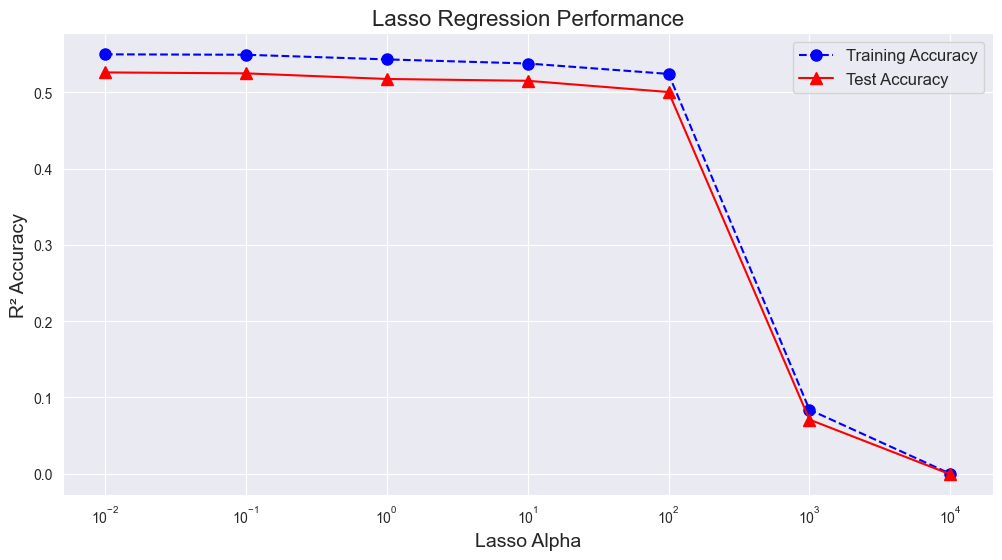

In [14]:
# Define alpha values
alpha_lasso = [0.01, 0.1, 1, 10, 100, 1000, 10000]

# Lists to store accuracy scores
training_accuracy = []
test_accuracy = []

# Train Lasso for different alpha values
for alpha_run in alpha_lasso:
    lasso = Lasso(alpha=alpha_run, max_iter=100000000).fit(X_train, y_train)
    training_accuracy.append(lasso.score(X_train, y_train))
    test_accuracy.append(lasso.score(X_test, y_test))

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(alpha_lasso, training_accuracy, label="Training Accuracy", color='blue', marker='o', linestyle='dashed', markersize=8)
plt.plot(alpha_lasso, test_accuracy, label="Test Accuracy", color='red', marker='^', linestyle='-', markersize=8)
plt.xscale("log")  # Log scale for better visualization
plt.xlabel("Lasso Alpha", fontsize=14)
plt.ylabel("R² Accuracy", fontsize=14)
plt.title("Lasso Regression Performance", fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()


# Conclusion

In conclusion, this project successfully explored different regression techniques to predict an individual's Financial Stability Score based on financial, demographic, and behavioral data. Among the models tested, Lasso Regression achieved the highest test accuracy (0.554463), closely followed by Ridge Regression (0.554272), while Linear Regression lagged behind with a test accuracy of 0.502629. The improved performance of Ridge and Lasso suggests that incorporating regularization helps enhance model generalization. These findings highlight the importance of selecting the right regression approach to achieve more accurate and reliable financial predictions.

